# FINAL PROJECT
## Probabilistic Risk for Domestic Violence Femicide: A Bayesian Network Model and Time-Based Adaptation of the Danger Assessment Instrument
#### Dr Alex Bevan

**Overview**

A survey called the Danger Assessment (created in Dr Jacquelyn Campbell 1986) is commonly used by police after a domestic violence incident to gauge the lethality of the case. It is a weighted 19 item yes/no questionnaire that outputs a score associated with one of four risk categories. Questions include “Does the perpetrator own a gun”” and “Has he threatened suicide?” These are the betas in effect. 90% of homicides score in the top two risk categories. The tool was designed based on a logistic regression applied to a restricted 11 city dataset of 310 cases against 324 control cases. In effect it provides a "distribution" that I would be working with as the equivalent of the clinical model we had in the first assignment. 

**Data** 
Data on domestic violence is notoriously difficult to access with IRB processing times stretching into months and institutions highly guarded about who accesses raw data. In order to best simulate real data, I've used news stories on femicide and attempted femicide from 2000 onwards and gleaned what information I can in order to fill out the Danger Assesment for these cases. This presents a huge selection bias but it's the best option I had

**Assumptions**
1. The Danger Assessment while accurate is dated, so this is assuming that the risk factors have not changed since its last revision which was in 2009. 
2. Same sex violence is sorely understudied in this area and is not represented here in the data
3. The models make the assumption that risk factors are independent, which in reality they are not

**Capstone** 
This is one small piece of the larger capstone I'm proposing that will optimize police patrol routes for domestic violence outcomes. 

Campbell, J. C. (1986). Nursing assessment for risk of homicide with battered women. Advances in Nursing Science, 8(4), 36–51. https://doi.org/10.1097/00012272-198607000-00006


### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pgmpy as pg
import arviz as az
import os
import subprocess, sys, importlib, collections, collections.abc
import probml_utils.pgmpy_utils as pgm


In [2]:
def _pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

# probml-utils: install directly from GitHub without heavy optional deps
# (jax/jaxlib in its requirements.txt fail to build on Python 3.10+)
_pip("git+https://github.com/probml/probml-utils.git", "--no-deps")

# Everything else the notebook actually uses
_pip("pgmpy", "graphviz", "causalgraphicalmodels", "numpy", "pandas")

# causalgraphicalmodels uses collections.Iterable, removed in Python 3.10.
# Restore it before the package is imported.
if not hasattr(collections, "Iterable"):
    collections.Iterable = collections.abc.Iterable

print("Setup complete.")


Setup complete.


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import itertools
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge, BIC, MaximumLikelihoodEstimator
from graphviz import Digraph
import networkx as nx

### 2. Encoding the Danger Assessment Tool into Bayes Net

This questionnaire comes from Campbell, J.C., Webster, D.W., & Glass, N. (2009). The Danger Assessment: Validation of a Lethality Risk Assessment Instrument for Intimate Partner Femicide. Journal of Interpersonal Violence. It is meant to be administered by police, social workers or other interventionist professionals but it's also widely available online for victims or others.

In [4]:
#This reproduces the quesitons in full with their weightings. 

questions_data = [
    (1, "Has the physical violence increased in severity or frequency over the past year?", 1),
    (2, "Does he own a gun?", 5),
    (3, "Have you left him after living together during the past year?", 4),
    (4, "Is he unemployed?", 4),
    (5, "Has he ever used a weapon against you or threatened you with a lethal weapon? (If yes, was the weapon a gun?)", 3),
    (6, "Does he threaten to kill you?", 3),
    (7, "Has he avoided being arrested for domestic violence?", 3), #This means that the offender has a history of DV but it's not in the system
    (8, "Do you have a child that is not his?", 2),
    (9, "Has he ever forced you to have sex when you did not wish to do so?", 2),
    (10, "Does he ever try to choke/strangle you or cut off your breathing? (If yes, has he done it more than once, or did it make you pass out, black out, or feel dizzy?)", 3),
    (11, "Does he use illegal drugs (e.g. amphetamines, meth, cocaine, crack, or other street drugs)?", 1),
    (12, "Is he an alcoholic or problem drinker?", 1),
    (13, "Does he control most or all of your daily activities (e.g. friends, family contact, money, car use)? (If he tries, but you do not let him, check here.)", 1),
    (14, "Is he violently and constantly jealous of you (e.g. \"If I can't have you, no one can\")?", 1),
    (15, "Have you ever been beaten by him while you were pregnant? (If you have never been pregnant by him, check here.)", 1),
    (16, "Has he ever threatened or tried to commit suicide?", 1),
    (17, "Does he threaten to harm your children?", 1),
    (18, "Do you believe he is capable of killing you?", 1),
    (19, "Does he follow or spy on you, leave threatening notes/messages, destroy your property, or call you when you don't want him to?", 1),
]

#The risk attached to the victim leaving decreases in the case that the victim and offender have never cohabitated
# This adjusts the victim left weighting to reflect this

NEVER_COHABITATED_ADJUSTMENT = -3  # overrides item 3's normal weighting when checked

def score_danger_assessment(answers, never_cohabitated=False):
    """
    answers: dict of {question_number: True/False} for "yes"/"no" responses
    never_cohabitated: True if item 3's "never lived with him" box was checked
    """
    total = 0
    for num, _, weight in questions_data:
        if num == 3 and never_cohabitated:
            total += NEVER_COHABITATED_ADJUSTMENT
            continue
        if answers.get(num):
            total += weight
    return total

danger_assessment_df = pd.DataFrame(questions_data, columns=["number", "question", "weighting"])

totals_row = pd.DataFrame([{
    "number": "Total",
    "question": "",
    "weighting": danger_assessment_df["weighting"].sum()
}])
danger_assessment_df = pd.concat([danger_assessment_df, totals_row], ignore_index=True)

danger_assessment_df


,number,question,weighting
0,1,Has the physical violence increased in severit...,1
1,2,Does he own a gun?,5
2,3,Have you left him after living together during...,4
3,4,Is he unemployed?,4
4,5,Has he ever used a weapon against you or threa...,3
5,6,Does he threaten to kill you?,3
6,7,Has he avoided being arrested for domestic vio...,3
7,8,Do you have a child that is not his?,2
8,9,Has he ever forced you to have sex when you di...,2
9,10,Does he ever try to choke/strangle you or cut ...,3


These are the risk scoring categories attached to four score ranges and their associated femicide rates

In [5]:
#Danger assessment scoring categories
danger_categories_df = pd.DataFrame([
    {"category": 1, "label": "Variable Danger",  "score_min": 0,  "score_max": 7,    "danger_group": "Categories 1-2", "pct_femicides_in_group": 10},
    {"category": 2, "label": "Increased Danger",  "score_min": 8,  "score_max": 13,   "danger_group": "Categories 1-2", "pct_femicides_in_group": 10},
    {"category": 3, "label": "Severe Danger",     "score_min": 14, "score_max": 17,   "danger_group": "Categories 3-4", "pct_femicides_in_group": 90},
    {"category": 4, "label": "Extreme Danger",    "score_min": 18, "score_max": None, "danger_group": "Categories 3-4", "pct_femicides_in_group": 90},
])
display(danger_categories_df)


def categorize_score(total_score):
    match = danger_categories_df[
        (danger_categories_df["score_min"] <= total_score) &
        ((danger_categories_df["score_max"].isna()) | (total_score <= danger_categories_df["score_max"]))
    ]
    return match.iloc[0][["category", "label"]].to_dict()


,category,label,score_min,score_max,danger_group,pct_femicides_in_group
0,1,Variable Danger,0,7.0,Categories 1-2,10
1,2,Increased Danger,8,13.0,Categories 1-2,10
2,3,Severe Danger,14,17.0,Categories 3-4,90
3,4,Extreme Danger,18,NaN,Categories 3-4,90


Building the Bayesian Net:
This entails translating the 19 questions to nodes each with an edge connected to lethality

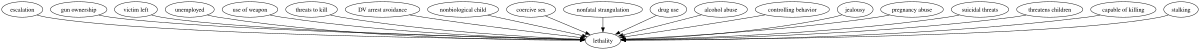

In [6]:
#Define the Edges and Nodes Based on Danger Assesment Model
model = DiscreteBayesianNetwork([
    ('escalation', 'lethality'),
    ('gun ownership', 'lethality'),
    ('victim left', 'lethality'),
    ('unemployed', 'lethality'),
    ('use of weapon', 'lethality'),
    ('threats to kill', 'lethality'),
    ('DV arrest avoidance', 'lethality'),
    ('nonbiological child', 'lethality'),
    ('coercive sex', 'lethality'),
    ('nonfatal strangulation', 'lethality'),
    ('drug use', 'lethality'),
    ('alcohol abuse', 'lethality'),
    ('controlling behavior', 'lethality'),
    ('jealousy', 'lethality'),
    ('pregnancy abuse', 'lethality'),
    ('suicidal threats', 'lethality'),
    ('threatens children', 'lethality'),
    ('capable of killing', 'lethality'),
    ('stalking', 'lethality')
])

graph = pgm.visualize_model(model)
graph.attr(size="8,6!")  
graph.attr(dpi="150")    
display(graph)

In [7]:
#Node_names: DA risk-factor labels, in the same order as questions_data (items 1-19)

node_names = [
    'escalation', 'gun ownership', 'victim left', 'unemployed', 'use of weapon',
    'threats to kill', 'DV arrest avoidance', 'nonbiological child', 'coercive sex',
    'nonfatal strangulation', 'drug use', 'alcohol abuse', 'controlling behavior',
    'jealousy', 'pregnancy abuse', 'suicidal threats', 'threatens children',
    'capable of killing', 'stalking'
]
assert len(node_names) == len(questions_data), "node_names must line up 1:1 with questions_data"


### 3. Encode Weights with Leaky Noisy-OR (Includes a Derived Prior)

**Noisy-OR:** This derives the CPT for each binary effect node. Here it is useful when many nodes share the same parent and saves you doing ALL the combinations by hand. The leaky noisy-OR model embeds a prior which is what I'm chosing to do here since we have the benefit of that information

**Where the weights come from:** The weights come from the questionaire tool where "yes" to some questions counts more than others as predictive of lethality. To convert them to the Noisy OR model, I've normalized them over the total score of the survey so 39 in this iteration.

**Calculating the Prior:** I'm applying Bayes theorem to derive the prior which has to be P (femicide | abuse). This equals P (abuse | femicide) * P (femicide) / P (abuse)

Piecing this together from several different studies, I found that:
P (femicide) = 1.2 / 100000. This is taken from the average of regional rates published by the UNODC 

P(abuse | femicide) = 80% I'm choosing the upper bound here to mitigate for underreporting. (Risk Factors for Femicide in Abusive Relationships: Results From a Multisite Case Control Study (Campbell et al., AJPH)https://ajph.aphapublications.org/doi/10.2105/AJPH.93.7.1089)

P(abuse) = 31.6% WHO's page Violence Against Women https://www.who.int/news-room/fact-sheets/detail/violence-against-women?form=MG0AV3&utm_source=chatgpt.com -- this is a *lifetime* prevalence.

Dividing the annual femicide rate straight into a lifetime abuse prevalence mixes two different time scales and understates lifetime risk, so I first scale the annual rate up by an assumed 40-year exposure window (adult years at meaningful risk) to get a comparable lifetime femicide rate. The 40 year window has a logic to it: Women on average live to be 81 years old and begin dating at a lower bound of 15 years. Let's assume (and this is not based in research at all) that 60% of that window is spend in relationships, then that would leave 39.6 years that women spend with intimate male partners.

Keep in mind this only includes the homicides that are solved *and* labeled as domestic violence. Furthermore it only includes the bodies that are found. 









#### Normalizing Weights over Total Survey Score to Feed into Noisy OR

In [8]:
 
#Prior Embedding: Baseline P(lethality=yes) when NONE of the modeled risk factors are present
p_femicide_annual = 1.2 / 100000       # CDC MMWR, 2018-2021 says .97 for US, but average of regional rates of UNODC yeilds this rate which is more of  a population match with the WHO stat
p_abuse_given_femicide = 0.80           # Campbell et al., upper bound for underreporting
p_abuse = 0.316                          # WHO lifetime prevalence
exposure_years = 40                      # assumed years of adult exposure at risk

#This is where a prior is embedded
p_leak = p_abuse_given_femicide * (p_femicide_annual * exposure_years) / p_abuse

total_weight = sum(weight for _, _, weight in questions_data)   # 39 is the total weight of all question if answered yes to everything

#This is how the weights are translated into the model
p_i = {
    name: weight / total_weight 
    for name, (_, _, weight) in zip(node_names, questions_data)
}

for name, (_, _, weight) in zip(node_names, questions_data):
    print(f"{name:25s} weight={weight:>2}  p_i={p_i[name]:.3f}")


#Small demo CPD of subset of 4 factors because the full CPD is 2**n or 2**19 which is 524,288 cols 
risk_factors = ['gun ownership', 'nonfatal strangulation', 'threats to kill', 'escalation']

def leaky_noisy_or(active_factors, p_i, p_leak):
    prob_not = (1 - p_leak)
    for f in active_factors:
        prob_not *= (1 - p_i[f])
    return 1 - prob_not

n = len(risk_factors)
combos = list(itertools.product([0, 1], repeat=n))  # 0 = absent, 1 = present; order matches pgmpy's column convention (state 0 first)

yes_row, no_row = [], []
for combo in combos:
    active = [f for f, present in zip(risk_factors, combo) if present == 1]
    p_yes = leaky_noisy_or(active, p_i, p_leak)
    yes_row.append(p_yes)
    no_row.append(1 - p_yes)
    
cpd_lethality2 = TabularCPD(
    variable='lethality', variable_card=2,
    evidence=risk_factors,
    evidence_card=[2] * n,
    values=[no_row, yes_row],
    state_names={'lethality': ['no', 'yes'], **{f: ['no', 'yes'] for f in risk_factors}},
)

#THe full untruncated width is 400+ columns so I'm choosing to keep the truncated iteration
os.environ["COLUMNS"] = "300"   
print(cpd_lethality2)



escalation                weight= 1  p_i=0.026
gun ownership             weight= 5  p_i=0.128
victim left               weight= 4  p_i=0.103
unemployed                weight= 4  p_i=0.103
use of weapon             weight= 3  p_i=0.077
threats to kill           weight= 3  p_i=0.077
DV arrest avoidance       weight= 3  p_i=0.077
nonbiological child       weight= 2  p_i=0.051
coercive sex              weight= 2  p_i=0.051
nonfatal strangulation    weight= 3  p_i=0.077
drug use                  weight= 1  p_i=0.026
alcohol abuse             weight= 1  p_i=0.026
controlling behavior      weight= 1  p_i=0.026
jealousy                  weight= 1  p_i=0.026
pregnancy abuse           weight= 1  p_i=0.026
suicidal threats          weight= 1  p_i=0.026
threatens children        weight= 1  p_i=0.026
capable of killing        weight= 1  p_i=0.026
stalking                  weight= 1  p_i=0.026
+------------------------+----------------------------+----------------------------+-----------------------

### 4. Encoding Time
This is a new contribution to the Danger Assesment. The questionnaire's initial question about escalation asks if abuse has intensified in the past year so we'll use that as the time window. 

We can have the escalation element be more granular in terms of recency and we can do the same for the victim leaving node. There is no consistently accepted decay curve for either incidents of leaving with regard to lethality. Recency windows are as short as two weeks from from other studies.

I went back and deleted the escalation node (weighted 1) and leaving node (weighted 4) and replaced them with these new nodes

**Victim left recency** node (w=4) with 5 time states
**Escalation recency** (w=1) has 5 time states

Time windows: within 2 weeks, 1 month, 3 months, 6 months, 1 year and weight these differently or score them differently. Monotonically decayed.

Weightings: If I weigh the time states to sum up to 1, then someone who would have answered escalation within 6 months now would get a lower score than before. So I'm chosing to push these past the original weights, adding a full point to each for any instance occuring within 2 weeks. 

In [9]:
#Remove the original nodes for escalation and leaving

nodes_to_remove = {'escalation', 'victim left'}

node_names, questions_data = zip(*[
    (name, q) for name, q in zip(node_names, questions_data)
    if name not in nodes_to_remove
])
node_names = list(node_names)
questions_data = list(questions_data)

for name in nodes_to_remove:
    if name in model.nodes():
        model.remove_node(name)


In [10]:
# #Insert victim left recency node with 6 states (5 decaying time buckets + "None" = never left)

victim_left_states = ['<2wks', '<1m', '<3m', '<6m', '<1yr', 'None']

# Linear decay in steps of 0.25, from the <2wks bucket down to <1yr, with "None" contributing 0.
victim_left_state_weight = {
    '<2wks': 5.0,
    '<1m':   4.75,
    '<3m':   4.5,
    '<6m':   4.25, 
    '<1yr':  4.0, #This person would still get a weight of 4 like before
    'None':  0.0,
}

# Per-state effect on lethality, consistent with normalized weight/total_weight scheme
p_i_victim_left_recency = {
    state: w / total_weight
    for state, w in victim_left_state_weight.items()
}

for state, p in p_i_victim_left_recency.items():
    print(f"{state:8s} weight={victim_left_state_weight[state]:.2f}  p_i={p:.4f}")

# Wire the node into the model
model.add_edge('victim_left_recency', 'lethality')

cpd_victim_left_recency = TabularCPD(
    variable='victim_left_recency', variable_card=6,
    values=[[1/6]] * 6,
    state_names={'victim_left_recency': victim_left_states},
)
node_names.append('victim_left_recency')


<2wks    weight=5.00  p_i=0.1282
<1m      weight=4.75  p_i=0.1218
<3m      weight=4.50  p_i=0.1154
<6m      weight=4.25  p_i=0.1090
<1yr     weight=4.00  p_i=0.1026
None     weight=0.00  p_i=0.0000


In [11]:
#Insert new escalation node with 6 states (5 decaying time buckets + "None" = no escalation) 
escalation_recency_states = ['<2wks', '<1m', '<3m', '<6m', '<1yr', 'None']

# Linear decay in steps of 0.25, from the <2wks bucket down to <1yr, with "None" contributing 0.
escalation_recency_weight = {
    '<2wks': 5.0,
    '<1m':   4.75,
    '<3m':   4.5,
    '<6m':   4.25,  
    '<1yr':  4.0, #This person would still get a weight of 4 like before
    'None':  0.0,
}

# Per-state effect on lethality, consistent with normalized weight/total_weight scheme
p_i_escalation_recency = {
    state: w / total_weight
    for state, w in escalation_recency_weight.items()
}

for state, p in p_i_escalation_recency.items():
    print(f"{state:8s} weight={escalation_recency_weight[state]:.2f}  p_i={p:.4f}")

# Wire the node into the model
model.add_edge('escalation_recency', 'lethality')

cpd_escalation_recency = TabularCPD(
    variable='escalation_recency', variable_card=6,
    values=[[1/6]] * 6,
    state_names={'escalation_recency': escalation_recency_states},
)

node_names.append('escalation_recency')


<2wks    weight=5.00  p_i=0.1282
<1m      weight=4.75  p_i=0.1218
<3m      weight=4.50  p_i=0.1154
<6m      weight=4.25  p_i=0.1090
<1yr     weight=4.00  p_i=0.1026
None     weight=0.00  p_i=0.0000


In [12]:
#Saving the full CPD to CSV file
all_risk_factors = node_names  # 17 binary risk factors + 2 time-based recency factors (6 states each)

recency_states = ['<2wks', '<1m', '<3m', '<6m', '<1yr', 'None']
recency_p_i = {
    'escalation_recency': p_i_escalation_recency,
    'victim_left_recency': p_i_victim_left_recency,
}

# cardinality per factor, in all_risk_factors order (2 for binary yes/no, 6 for recency)
evidence_card = [len(recency_states) if f in recency_p_i else 2 for f in all_risk_factors]

# per-factor, per-state contribution to the noisy-OR leak probability:
# binary factors  -> [p(absent)=0, p(present)=p_i[f]]
# recency factors -> p_i for each state, in recency_states order
factor_state_p = [
    [recency_p_i[f][state] for state in recency_states] if f in recency_p_i else [0.0, p_i[f]]
    for f in all_risk_factors
]

n_all = len(all_risk_factors)

combos_all = np.array(list(itertools.product(*[range(c) for c in evidence_card])))  

# log(1-P) = log(1-p_leak) + sum_i log(1 - p_i for the state selected on factor i)
log_survival = np.log(1 - p_leak) * np.ones(combos_all.shape[0])
for j, state_p in enumerate(factor_state_p):
    log_survival += np.log(1 - np.array(state_p)[combos_all[:, j]])

p_yes_all = 1 - np.exp(log_survival)
p_no_all = 1 - p_yes_all

cpd_lethality_full = TabularCPD(
    variable='lethality', variable_card=2,
    evidence=all_risk_factors,
    evidence_card=evidence_card,
    values=np.vstack([p_no_all, p_yes_all]),
    state_names={
        'lethality': ['no', 'yes'],
        **{f: (recency_states if f in recency_p_i else ['no', 'yes']) for f in all_risk_factors},
    },
)

cpd_table_full = pd.DataFrame(combos_all, columns=all_risk_factors)
cpd_table_full['P(lethality=yes)'] = p_yes_all
cpd_table_full.to_csv('lethality_cpd_full.csv', index=False)

print(f"Full CPD: {cpd_table_full.shape[0]:,} rows x {cpd_table_full.shape[1]} columns")
print("Saved to lethality_cpd_full.csv\n")

# Highest-risk combinations (all binary factors present, recency factors at their most-recent bucket)
cpd_table_full.sort_values('P(lethality=yes)', ascending=False).head(20)

Full CPD: 4,718,592 rows x 20 columns
Saved to lethality_cpd_full.csv



,gun ownership,unemployed,use of weapon,threats to kill,DV arrest avoidance,nonbiological child,coercive sex,nonfatal strangulation,drug use,alcohol abuse,controlling behavior,jealousy,pregnancy abuse,suicidal threats,threatens children,capable of killing,stalking,victim_left_recency,escalation_recency,P(lethality=yes)
4718556,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0.692804
4718562,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0.690546
4718557,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0.690546
4718568,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,0,0.688287
4718558,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,2,0.688287
4718563,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.688270
4718559,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,3,0.686028
4718574,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,0,0.686028
4718569,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,0.685995
4718564,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,0.685995


Note that the highest P is 69% which is a fairly weak signal for traditional models with a threshold of 50%

In [ ]:
# CPD of a subset of factors -- same idea as the earlier 4-factor demo, but now
#handles both binary factors and the 6-state recency factors since the full CPD is mixed.
demo_factors = ['gun ownership', 'nonfatal strangulation', 'threats to kill', 'escalation_recency']

demo_evidence_card = [len(recency_states) if f in recency_p_i else 2 for f in demo_factors]
demo_factor_state_p = [
    [recency_p_i[f][state] for state in recency_states] if f in recency_p_i else [0.0, p_i[f]]
    for f in demo_factors
]

demo_combos = list(itertools.product(*[range(c) for c in demo_evidence_card]))

yes_row, no_row = [], []
for combo in demo_combos:
    prob_not = (1 - p_leak)
    for state_p, state_idx in zip(demo_factor_state_p, combo):
        prob_not *= (1 - state_p[state_idx])
    p_yes = 1 - prob_not
    yes_row.append(p_yes)
    no_row.append(1 - p_yes)

cpd_demo = TabularCPD(
    variable='lethality', variable_card=2,
    evidence=demo_factors,
    evidence_card=demo_evidence_card,
    values=[no_row, yes_row],
    state_names={
        'lethality': ['no', 'yes'],
        **{f: (recency_states if f in recency_p_i else ['no', 'yes']) for f in demo_factors},
    },
)

os.environ["COLUMNS"] = "300"   # wide enough that pgmpy won't truncate
print(cpd_demo)


+------------------------+----------------------------+----------------------------+----------------------------+----------------------------+-----+-----------------------------+-----------------------------+-----------------------------+-----------------------------+
| gun ownership          | gun ownership(no)          | gun ownership(no)          | gun ownership(no)          | gun ownership(no)          | ... | gun ownership(yes)          | gun ownership(yes)          | gun ownership(yes)          | gun ownership(yes)          |
+------------------------+----------------------------+----------------------------+----------------------------+----------------------------+-----+-----------------------------+-----------------------------+-----------------------------+-----------------------------+
| nonfatal strangulation | nonfatal strangulation(no) | nonfatal strangulation(no) | nonfatal strangulation(no) | nonfatal strangulation(no) | ... | nonfatal strangulation(yes) | nonfatal stran

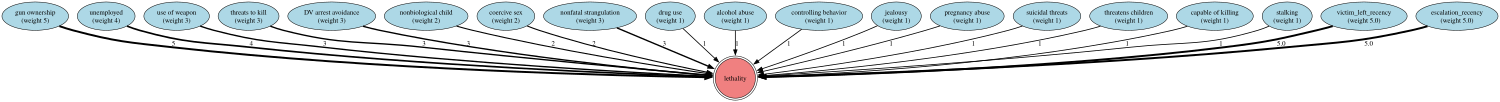

In [14]:
from graphviz import Digraph

recency_cpds = {
    'victim_left_recency': cpd_victim_left_recency,
    'escalation_recency': cpd_escalation_recency,
}
root_cpds = [
    recency_cpds[name] if name in recency_cpds
    else TabularCPD(variable=name, variable_card=2, values=[[0.5], [0.5]], state_names={name: ['no', 'yes']})
    for name in all_risk_factors
]
model.add_cpds(cpd_lethality_full, *root_cpds)
model.check_model()

# pgm.visualize_model() embeds each node's full CPD as an HTML table in its label --
# fine for small CPDs, but lethality's has millions of rows, so that approach can't be used
# here. Instead, draw the DAG directly and encode each factor's DA weight as edge
# thickness/label. Binary factors have one weight; the two recency factors have one weight
# per time bucket, so their label/thickness uses the max (most-recent, <2wks) bucket as a
# representative value.
weight_lookup = {name: weight for name, (_, _, weight) in zip(node_names, questions_data)}
# node_names is longer than questions_data now (the two recency nodes were appended after
# replacing 'escalation'/'victim left', and they don't have a single scalar weight), so add
# their representative weights by hand.
weight_lookup['victim_left_recency'] = max(victim_left_state_weight.values())
weight_lookup['escalation_recency'] = max(escalation_recency_weight.values())
max_weight = max(weight_lookup.values())

dag = Digraph('weighted_model')
dag.attr(size="10,8!", dpi="150")
dag.attr('node', shape='ellipse', style='filled', fillcolor='lightblue')

for name in all_risk_factors:
    dag.node(name, label=f"{name}\n(weight {weight_lookup[name]})")
dag.node('lethality', shape='doublecircle', style='filled', fillcolor='lightcoral')

for name in all_risk_factors:
    w = weight_lookup[name]
    dag.edge(name, 'lethality', label=str(w), penwidth=str(1 + 3 * w / max_weight))

display(dag)

### 5. Case Studies
The case studies are loosely based in real women I knew in the survivor communities in Australia and Chicago


#### Case 1 Inference


In [15]:
#Define an inference object
infer = VariableElimination(model)

#Binary factors: 'yes' / 'no'. Recency factors: '<2wks', '<1m', '<3m', '<6m', '<1yr', or 'None'.
evidence1 = {
    'gun ownership':          'no',
    'unemployed':              'no',
    'use of weapon':           'no',
    'threats to kill':         'no',
    'DV arrest avoidance':     'yes',
    'nonbiological child':     'no',
    'coercive sex':            'yes',
    'nonfatal strangulation':  'yes',
    'drug use':                'no',
    'alcohol abuse':           'yes',
    'controlling behavior':    'yes',
    'jealousy':                'yes',
    'pregnancy abuse':         'no',
    'suicidal threats':        'no',
    'threatens children':      'no',
    'capable of killing':      'yes',
    'stalking':                'no',
    'victim_left_recency':     '<1yr',
    'escalation_recency':      '<1m',
}
assert set(evidence1.keys()) == set(node_names), "evidence keys must match node_names exactly"

#Have the model output posterior probabilities based on evidence
result_case1 = infer.query(variables=["lethality"], evidence=evidence1)
print(result_case1)


+----------------+------------------+
| lethality      |   phi(lethality) |
+================+==================+
| lethality(no)  |           0.5735 |
+----------------+------------------+
| lethality(yes) |           0.4265 |
+----------------+------------------+


#### Case 2 Inference  


In [16]:
#Define an inference object
infer = VariableElimination(model)

#Binary factors: 'yes' / 'no'. Recency factors: '<2wks', '<1m', '<3m', '<6m', '<1yr', or 'None'.
evidence2 = {
    'gun ownership':          'no',
    'unemployed':              'yes',
    'use of weapon':           'no',
    'threats to kill':         'no',
    'DV arrest avoidance':     'yes',
    'nonbiological child':     'no',
    'coercive sex':            'yes',
    'nonfatal strangulation':  'no',
    'drug use':                'yes',
    'alcohol abuse':           'yes',
    'controlling behavior':    'yes',
    'jealousy':                'yes',
    'pregnancy abuse':         'no',
    'suicidal threats':        'yes',
    'threatens children':      'no',
    'capable of killing':      'yes',
    'stalking':                'yes',
    'victim_left_recency':     '<1yr',
    'escalation_recency':      '<2wks',
}
assert set(evidence2.keys()) == set(node_names), "evidence keys must match node_names exactly"

#Have the model output posterior probabilities based on evidence
result_case2 = infer.query(variables=["lethality"], evidence=evidence2)
print(result_case2)


+----------------+------------------+
| lethality      |   phi(lethality) |
+================+==================+
| lethality(no)  |           0.5120 |
+----------------+------------------+
| lethality(yes) |           0.4880 |
+----------------+------------------+


#### Case 3 Inference


In [17]:
#Define an inference object
infer = VariableElimination(model)

#Binary factors: 'yes' / 'no'. Recency factors: '<2wks', '<1m', '<3m', '<6m', '<1yr', or 'None'.
evidence3 = {
    'gun ownership':          'yes',
    'unemployed':              'no',
    'use of weapon':           'yes',
    'threats to kill':         'yes',
    'DV arrest avoidance':     'yes',
    'nonbiological child':     'yes',
    'coercive sex':            'no',
    'nonfatal strangulation':  'yes',
    'drug use':                'no',
    'alcohol abuse':           'yes',
    'controlling behavior':    'yes',
    'jealousy':                'yes',
    'pregnancy abuse':         'yes',
    'suicidal threats':        'no',
    'threatens children':      'no',
    'capable of killing':      'yes',
    'stalking':                'yes',
    'victim_left_recency':     '<3m',
    'escalation_recency':      '<1m',
}
assert set(evidence3.keys()) == set(node_names), "evidence keys must match node_names exactly"

#Have the model output posterior probabilities based on evidence
result_case3 = infer.query(variables=["lethality"], evidence=evidence3)
print(result_case3)


+----------------+------------------+
| lethality      |   phi(lethality) |
+================+==================+
| lethality(no)  |           0.3987 |
+----------------+------------------+
| lethality(yes) |           0.6013 |
+----------------+------------------+


### 6.  Training the Net with Real Data

I want to use Hill Climb and MLE to find new interrelationships in the DAG and to make predictions. So I fed this prompt to Claude: 

*"This task will probably entail a research agent. I want you to pull news stories of femicide and attempted femicides in domestic violence intimate partner relationships in straight couples in the USA between 2000 and 2026. I need you to create a dataframe with each case (denoted by lethality or not, date of newstory, and location) as a separate row with the points allotted to each of these questions. Total score as separate column. Please collect about 1000 data points of the stories that have the answers to the most questions."*

Some back and forth narrowed it down to 2015-2026 and including pending cases. The dataset Claude returned included 68 fatal and 18 attempted cases in the US. The df was sparse with an average of 2.9 out of 19 questions answered. Certain categories were particularly sparse because these are rarely reported by news. For these categories I imputed data based on the probability of risk factors given abusive relationships. These included:

Coercive sex 14.9%
Drug use 30%
Pregnancy abuse 8.4%
Unemployment 20.2%
Capable of killing 23%
Nonbio chid 17.5%

I then asked Claude to split the cases that were lethal on the event leading up to the fatality and making those cases synthetic cases ending in survival. This resulted in a df that was 154 rows


In [18]:
#Import the df
df = pd.read_csv("/Users/alexbevan/Desktop/Final Projects/Bayesian/Bayes DF/final_df_manual_cohab.csv")
print(df.shape)  
print(df.columns)

#Look at missingness as percentage
(df.isna().mean() * 100).round(1).sort_values(ascending=False)

#Look at number of lethal versus nonlethal cases
print(df.value_counts('lethality'))

(154, 49)
Index(['case_id', 'victim_name', 'perpetrator_name', 'date_of_incident',
       'date_of_story', 'source_outlet', 'source_url', 'location_city',
       'location_state', 'lethality', 'case_status', 'q1_escalation',
       'q2_gun_ownership', 'q3_left_recently', 'q3_never_cohabitated',
       'q3_adjustment_note', 'q4_unemployed', 'q4_unemployed_imputed',
       'q5_weapon_threat', 'q5_weapon_was_gun', 'q6_threatens_kill',
       'q7_avoided_arrest', 'q8_nonbio_child', 'q8_nonbio_child_imputed',
       'q9_coercive_sex', 'q9_coercive_sex_imputed', 'q10_strangulation',
       'q10_severity_note', 'q11_drug_use', 'q11_drug_use_imputed',
       'q12_alcohol_abuse', 'q12_alcohol_abuse_imputed', 'q13_controlling',
       'q14_jealousy', 'q15_pregnancy_abuse', 'q15_pregnancy_abuse_imputed',
       'q16_suicidal_threats', 'q16_suicidal_threats_imputed',
       'q17_threatens_children', 'q18_capable_of_killing',
       'q18_capable_of_killing_imputed', 'q19_stalking', 'total_score',
 

The survivor majority class is 56% and lethality majority class is 44%

In [19]:
#Dropping columns that shouldn't go into the model
dfcopy = df.copy()

keep_cols = [
    'case_id', 'lethality', 'q1_escalation', 'q2_gun_ownership', 'q3_left_recently',
    'q4_unemployed', 'q5_weapon_threat', 'q6_threatens_kill',
    'q7_avoided_arrest', 'q8_nonbio_child', 'q9_coercive_sex', 'q10_strangulation',
    'q11_drug_use', 'q12_alcohol_abuse', 'q13_controlling', 'q14_jealousy',
    'q15_pregnancy_abuse', 'q16_suicidal_threats', 
    'q17_threatens_children', 'q18_capable_of_killing', 'q19_stalking'
]

df = df.drop(columns=df.columns.difference(keep_cols))
df = df.fillna(0)

#Test train split that preserves the synthetic iterations
#First we need to make sure that the original case and its synthetic iteration go to the same group - test or train because otherwise, the near duplicates may present leakage
df['case_root'] = df['case_id'].str.replace('-SYN', '', regex=False)

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['case_root']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]


I tried Hill Climb because the optimizer has the best reputation for small datasets

In [20]:
# Hill Climb search over ALL nodes (risk factors + lethality). 
# Lethality is forbidden from being a source (it can't cause a risk factor),so it stays consequence in the DAG.


feature_cols = [c for c in train_df.columns if c.startswith('q')]
factor_data = train_df[feature_cols]

full_data = train_df[feature_cols + ['lethality']]

expert_knowledge = ExpertKnowledge(
    forbidden_edges=[('lethality', f) for f in feature_cols]
)

hc = HillClimbSearch(full_data)
hc_dag = hc.estimate(
    scoring_method=BIC(full_data),
    expert_knowledge=expert_knowledge,
    max_indegree=4,       # keep CPDs from blowing up combinatorially
    show_progress=False,
)

print(f"Hill Climb DAG: {len(hc_dag.edges())} edges\n")
for u, v in hc_dag.edges():
    print(f"  {u} -> {v}")

added_edges = []
for f in feature_cols:
    if not nx.has_path(hc_dag, f, 'lethality'):
        hc_dag.add_edge(f, 'lethality')
        added_edges.append(f)

if added_edges:
    print(f"\nAdded direct edges to lethality for previously disconnected factors: {added_edges}")
else:
    print("\nEvery factor already had a path to lethality -- no fallback edges needed.")

learned_model = DiscreteBayesianNetwork(hc_dag.edges())

bic = BIC(full_data)
bic_value = bic.score(learned_model)
print(f"\nBIC score: {bic_value:.2f}")







INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'q1_escalation': 'N', 'q2_gun_ownership': 'N', 'q3_left_recently': 'N', 'q4_unemployed': 'N', 'q5_weapon_threat': 'N', 'q6_threatens_kill': 'N', 'q7_avoided_arrest': 'N', 'q8_nonbio_child': 'N', 'q9_coercive_sex': 'N', 'q10_strangulation': 'N', 'q11_drug_use': 'N', 'q12_alcohol_abuse': 'N', 'q13_controlling': 'N', 'q14_jealousy': 'N', 'q15_pregnancy_abuse': 'N', 'q16_suicidal_threats': 'N', 'q17_threatens_children': 'N', 'q18_capable_of_killing': 'N', 'q19_stalking': 'N', 'lethality': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'q1_escalation': 'N', 'q2_gun_ownership': 'N', 'q3_left_recently': 'N', 'q4_unemployed': 'N', 'q5_weapon_threat': 'N', 'q6_threatens_kill': 'N', 'q7_avoided_arrest': 'N', 'q8_nonbio_child': 'N', 'q9_coercive_sex': 'N', 'q10_strangulation': 'N', 'q11_drug_use': 'N', 'q12_alcohol_abuse': 'N', '

Hill Climb DAG: 18 edges

  q1_escalation -> q17_threatens_children
  q2_gun_ownership -> q9_coercive_sex
  q4_unemployed -> q13_controlling
  q5_weapon_threat -> lethality
  q5_weapon_threat -> q2_gun_ownership
  q7_avoided_arrest -> q8_nonbio_child
  q9_coercive_sex -> q16_suicidal_threats
  q10_strangulation -> q2_gun_ownership
  q10_strangulation -> q9_coercive_sex
  q11_drug_use -> q13_controlling
  q13_controlling -> q14_jealousy
  q14_jealousy -> q18_capable_of_killing
  q15_pregnancy_abuse -> q13_controlling
  q17_threatens_children -> q6_threatens_kill
  q17_threatens_children -> q18_capable_of_killing
  q17_threatens_children -> q12_alcohol_abuse
  q18_capable_of_killing -> q19_stalking
  q19_stalking -> q7_avoided_arrest

Added direct edges to lethality for previously disconnected factors: ['q1_escalation', 'q2_gun_ownership', 'q3_left_recently', 'q4_unemployed', 'q6_threatens_kill', 'q7_avoided_arrest', 'q8_nonbio_child', 'q9_coercive_sex', 'q12_alcohol_abuse', 'q16_suicida

Note: We can't really compare this to a BIC rooted in the expert model because BIC is really data based and there will be a parameter mismatch

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'q1_escalation': 'N', 'q2_gun_ownership': 'N', 'q3_left_recently': 'N', 'q4_unemployed': 'N', 'q5_weapon_threat': 'N', 'q6_threatens_kill': 'N', 'q7_avoided_arrest': 'N', 'q8_nonbio_child': 'N', 'q9_coercive_sex': 'N', 'q10_strangulation': 'N', 'q11_drug_use': 'N', 'q12_alcohol_abuse': 'N', 'q13_controlling': 'N', 'q14_jealousy': 'N', 'q15_pregnancy_abuse': 'N', 'q16_suicidal_threats': 'N', 'q17_threatens_children': 'N', 'q18_capable_of_killing': 'N', 'q19_stalking': 'N', 'lethality': 'N'}



CPD for q1_escalation:
+---------------------+-----------+
| q1_escalation(0.0)  | 0.865248  |
+---------------------+-----------+
| q1_escalation(1.5)  | 0.0141844 |
+---------------------+-----------+
| q1_escalation(1.75) | 0.0283688 |
+---------------------+-----------+
| q1_escalation(2.0)  | 0.0921986 |
+---------------------+-----------+

CPD for q17_threatens_children:
+-----------------------------+---------------------+--------------------+---------------------+---------------------+
| q1_escalation               | q1_escalation(0.0)  | q1_escalation(1.5) | q1_escalation(1.75) | q1_escalation(2.0)  |
+-----------------------------+---------------------+--------------------+---------------------+---------------------+
| q17_threatens_children(0.0) | 0.9918032786885246  | 1.0                | 1.0                 | 0.6153846153846154  |
+-----------------------------+---------------------+--------------------+---------------------+---------------------+
| q17_threatens_children

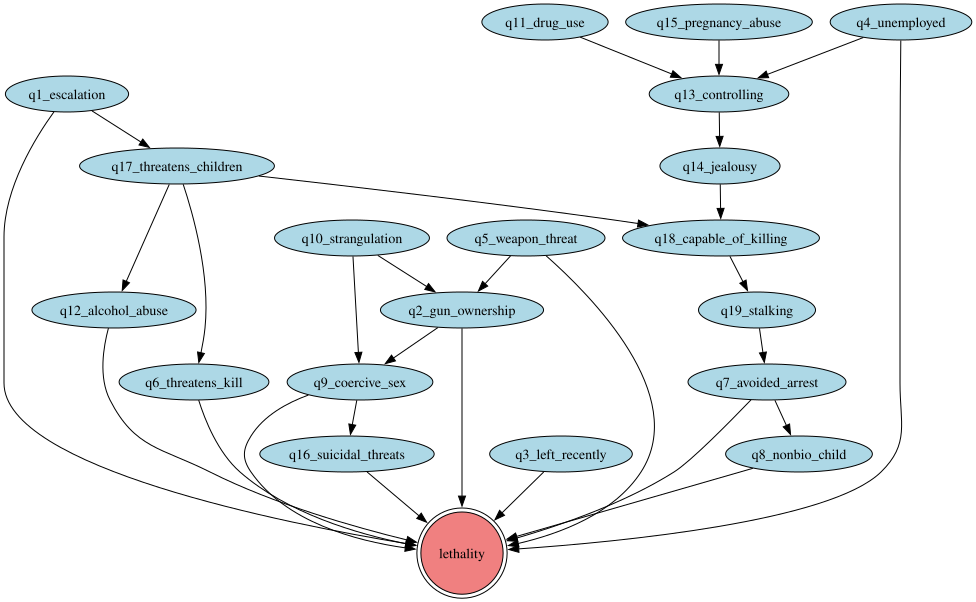

In [21]:
#Extract the CPDs

mle = MaximumLikelihoodEstimator(learned_model, full_data)
cpds = mle.get_parameters()
learned_model.add_cpds(*cpds)
learned_model.check_model()

for cpd in learned_model.get_cpds():
    print(f"\nCPD for {cpd.variable}:")
    print(cpd)

dag_plot = Digraph('hill_climb_full')
dag_plot.attr('node', shape='ellipse', style='filled', fillcolor='lightblue')
dag_plot.node('lethality', shape='doublecircle', style='filled', fillcolor='lightcoral')
for u, v in learned_model.edges():
    dag_plot.edge(u, v)
display(dag_plot)

What do we make of this dag? It's more reflective of how news constructs DV rather than DV itself. I don't think it can be used to give adequate probabilistic predictions but it can be used as an analysis tool of the news coverage and the story that is commonly told about DV. Strangulation, weapon threats, escalation, and controlling behavior are the big 'markers' of DV relationships in the news and drivers of all the other risk factors. Escalation, by contrast, shows up here as a downstream consequence rather than a driver -- its only edge among the risk factors is incoming (from threatens-children), so in this DAG it looks more like a symptom of the narrative than a trigger.These are the big presences in the storytelling about DV. These may be attached to the interview questions reporters are accustomed to asking in such contexts rather than endemic to the cases themselves. Leaving recently is also important but is represented here in isolation in terms of its effect on lethality. The other parent nodes were also features I imputed so I coulnd't really comment on how news stories framed these areas like pregnancy abuse, unemployment, etc. 

### 7. Evaluation Metrics & Visualizations



In [22]:
#Predicting on test set
from sklearn.metrics import accuracy_score, classification_report


test_evidence = test_df[feature_cols]
test_actual = test_df['lethality']

hc_predictions = learned_model.predict(test_evidence, n_jobs=1)

accuracy = accuracy_score(test_actual, hc_predictions['lethality'])
print(f"Hill Climb model test accuracy: {accuracy:.3f}\n")
print(classification_report(test_actual, hc_predictions['lethality']))


  0%|          | 0/9 [00:00<?, ?it/s]

Hill Climb model test accuracy: 0.615

              precision    recall  f1-score   support

           0       0.67      0.89      0.76         9
           1       0.00      0.00      0.00         4

    accuracy                           0.62        13
   macro avg       0.33      0.44      0.38        13
weighted avg       0.46      0.62      0.53        13



The Hill Climb model run on the news stories test set (very small in size) shows the model did not accurately predict lethality at all. I think this is the disparateness between newscoverage and real life dynamics. The model misses all the lethal cases. The model is BELOW the naive majority class baseline (0.69). These poor results are really the result of the lethality CPD being 50/50 as a result of the combination of the small sample size and the class imbalance. The clinicians model undoubtably is better based on its reported accuracy metrics. 


### 8. Case Studies Using Data-Driven Model

#### Case Study 1

In [23]:
# Run Case 1 (evidence1) against the Hill Climb model instead of the clinicians' model.
infer_hc = VariableElimination(learned_model)

# node_names label (clinicians' model) -> Hill Climb column name
NODE_TO_Q = {
    'gun ownership':          'q2_gun_ownership',
    'unemployed':              'q4_unemployed',
    'use of weapon':           'q5_weapon_threat',
    'threats to kill':         'q6_threatens_kill',
    'DV arrest avoidance':     'q7_avoided_arrest',
    'nonbiological child':     'q8_nonbio_child',
    'coercive sex':            'q9_coercive_sex',
    'nonfatal strangulation':  'q10_strangulation',
    'drug use':                'q11_drug_use',
    'alcohol abuse':           'q12_alcohol_abuse',
    'controlling behavior':    'q13_controlling',
    'jealousy':                'q14_jealousy',
    'pregnancy abuse':         'q15_pregnancy_abuse',
    'suicidal threats':        'q16_suicidal_threats',
    'threatens children':      'q17_threatens_children',
    'capable of killing':      'q18_capable_of_killing',
    'stalking':                'q19_stalking',
    'victim_left_recency':     'q3_left_recently',
    'escalation_recency':      'q1_escalation',
}

RECENCY_RANK = ['None', '<1yr', '<6m', '<3m', '<1m', '<2wks']  # least -> most recent

def recency_to_q_state(qvar, label):
    """Map a recency label onto the nearest state the Hill Climb model actually
    learned for qvar, by ORDINAL RANK rather than raw weight value -- q1_escalation
    and q3_left_recently were coded on different numeric scales in the source data
    (see markdown above), so absolute weights aren't directly comparable."""
    states = sorted(learned_model.get_cpds(qvar).state_names[qvar])  # ascending, 0.0 first
    rank = RECENCY_RANK.index(label)
    idx = round(rank / (len(RECENCY_RANK) - 1) * (len(states) - 1))
    return states[idx]

evidence1_hc = {}
for node, value in evidence1.items():
    if node not in NODE_TO_Q:
        continue  # not part of the Hill Climb feature set
    qvar = NODE_TO_Q[node]
    if qvar not in learned_model.nodes():
        continue  # BIC search / safety net still dropped this factor
    if node in ('victim_left_recency', 'escalation_recency'):
        evidence1_hc[qvar] = recency_to_q_state(qvar, value)
    else:
        states = learned_model.get_cpds(qvar).state_names[qvar]
        nonzero = [s for s in states if s != 0.0]
        evidence1_hc[qvar] = (max(nonzero) if nonzero else 0.0) if value == 'yes' else 0.0

print("Hill Climb evidence:", evidence1_hc)

result_case1_hc = infer_hc.query(variables=['lethality'], evidence=evidence1_hc)
print(result_case1_hc)


Hill Climb evidence: {'q2_gun_ownership': 0.0, 'q4_unemployed': 0.0, 'q5_weapon_threat': 0.0, 'q6_threatens_kill': 0.0, 'q7_avoided_arrest': np.float64(3.0), 'q8_nonbio_child': 0.0, 'q9_coercive_sex': np.int64(2), 'q10_strangulation': np.float64(3.0), 'q11_drug_use': 0.0, 'q12_alcohol_abuse': np.int64(1), 'q13_controlling': np.float64(1.0), 'q14_jealousy': np.float64(1.0), 'q15_pregnancy_abuse': 0.0, 'q16_suicidal_threats': 0.0, 'q17_threatens_children': 0.0, 'q18_capable_of_killing': np.int64(1), 'q19_stalking': 0.0, 'q3_left_recently': np.float64(4.0), 'q1_escalation': np.float64(1.75)}
+--------------+------------------+
| lethality    |   phi(lethality) |
+==============+==================+
| lethality(0) |           0.5000 |
+--------------+------------------+
| lethality(1) |           0.5000 |
+--------------+------------------+


The other two case studies will likely be the same due to the small sample size

### 9. Apply the Expert-Driven Model With my Time Modifications to the Test Set


My time nodes were not really given a chance ot shine here because I had no real data but let's run the test set through that model anyway and see what happens

In [26]:
from sklearn.metrics import accuracy_score, classification_report

# Uses the SAME `model` as your Case 1/2/3 inferences (escalation_recency and
# victim_left_recency included).
#
# Both raw columns encode recency directly, just on different base weights (see
# markdown above: escalation base=1, victim-left base=4, both +0.25/bucket up to
# +1 full point at <2wks):
#   victim_left_recency: q3_left_recently in {4.0, 4.25, 4.5, 4.75, 5.0} -> bucket
#   escalation_recency:  q1_escalation   in {1.0, 1.25, 1.5, 1.75, 2.0} -> bucket
# Both map through their own raw-value -> state lookup rather than collapsing
# every nonzero value to '<1yr'.
#
# Every risk-factor column is weight-coded in the raw data (0/blank = absent,
# the item's DA weight = present -- e.g. strangulation's "3"), not clean 0/1.
# `to_yes_no` checks only `v == 0`, so it's robust to whatever weight value shows
# up, unlike a fixed {0:.., 1:..} dict.
def to_yes_no(series):
    return series.map(lambda v: 'no' if v == 0 else 'yes')

original_node_names = [
    'escalation', 'gun ownership', 'victim left', 'unemployed', 'use of weapon',
    'threats to kill', 'DV arrest avoidance', 'nonbiological child', 'coercive sex',
    'nonfatal strangulation', 'drug use', 'alcohol abuse', 'controlling behavior',
    'jealousy', 'pregnancy abuse', 'suicidal threats', 'threatens children',
    'capable of killing', 'stalking'
]
binary_pairs = [(q, n) for q, n in zip(feature_cols, original_node_names)
                if n not in ('escalation', 'victim left')]

binary_evidence = (
    test_df[[q for q, n in binary_pairs]]
    .rename(columns=dict(binary_pairs))
    .apply(to_yes_no)
)

victim_left_weight_to_state = {w: s for s, w in victim_left_state_weight.items()}

# Escalation's raw scale is base=1 (+0.25/bucket, +1 at <2wks), NOT the same
# numbers as escalation_recency_weight (which is base=4, used only for the CPD's
# normalized probabilities) -- build the raw-value lookup on escalation's own scale.
escalation_raw_weight_to_state = {
    0.0:  'None',
    1.0:  '<1yr',
    1.25: '<6m',
    1.5:  '<3m',
    1.75: '<1m',
    2.0:  '<2wks',
}

recency_evidence = pd.DataFrame({
    'escalation_recency': test_df['q1_escalation'].map(
        lambda v: 'None' if pd.isna(v) else escalation_raw_weight_to_state[v]
    ),
    'victim_left_recency': test_df['q3_left_recently'].map(
        lambda v: 'None' if pd.isna(v) else victim_left_weight_to_state[v]
    ),
}, index=test_df.index)
from sklearn.metrics import roc_auc_score, roc_curve

expert_test_evidence = pd.concat([binary_evidence, recency_evidence], axis=1)
test_actual_labels = to_yes_no(test_df['lethality'])

expert_probs = model.predict_probability(expert_test_evidence)['lethality_yes']
test_actual_binary = (test_df['lethality'] == 1).astype(int)

auc = roc_auc_score(test_actual_binary, expert_probs)
print(f"ROC-AUC: {auc:.3f}  (0.5 = random, 1.0 = perfect separation)\n")

fpr, tpr, thresholds = roc_curve(test_actual_binary, expert_probs)


# Youden's J = tpr - fpr, maximized at the threshold that best trades off the two
# error types on THIS test set. Reported for reference only -- with just 13 rows,
# tuning the threshold on the same data it's evaluated on would overstate
# performance, so it's not applied to the metrics below.
best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]
print(f"Youden's-J-optimal threshold on this test set: {best_threshold:.3f}")
print(f"  (tpr={tpr[best_idx]:.3f}, fpr={fpr[best_idx]:.3f})\n")

preds = (expert_probs >= 0.5).map({True: 'yes', False: 'no'})

print(f"Accuracy at 0.5 threshold: {accuracy_score(test_actual_labels, preds):.3f}\n")
print(classification_report(test_actual_labels, preds))


ROC-AUC: 0.556  (0.5 = random, 1.0 = perfect separation)

Youden's-J-optimal threshold on this test set: 0.125
  (tpr=1.000, fpr=0.778)

Accuracy at 0.5 threshold: 0.692

              precision    recall  f1-score   support

          no       0.69      1.00      0.82         9
         yes       0.00      0.00      0.00         4

    accuracy                           0.69        13
   macro avg       0.35      0.50      0.41        13
weighted avg       0.48      0.69      0.57        13



/opt/anaconda3/envs/bayes_ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bayes_ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bayes_ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

The combination of the small dataset + most cases not having the 19 pieces of information needed results in underperformance in general. 
At the standard 0.5 threshold, the model collapses to predicting 'no' for every case in the test set -- it catches none of the 4 actual lethal cases (recall 0.00), the same degenerate majority-class behavior seen from the Hill Climb model. The 0.692 accuracy looks reasonable on the surface but is identical to just always guessing 'not lethal.' This tracks with how sparse the news-derived cases are: with only a handful of the 19 risk factors ever confirmed per case, the model's raw P(yes) rarely climbs past 0.5, even for genuinely lethal cases.

That's exactly why a lower threshold is worth considering here: at the Youden's-J-optimal cutoff of 0.125 (reported above but not applied to these metrics), the model would catch all 4 lethal cases, at the cost of far more false alarms. In a lethality-risk context, trading more red flags for not missing a real threat is arguably the right call -- though the 0.125 value itself is tuned and evaluated on the same 13-row test set, so treat it as where a threshold could sit rather than a number to ship without a proper validation split.



In [27]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

THRESHOLDS = [0.5, 0.125]  # 0.5 = original default threshold, 0.125 = lowered threshold

def evaluate_at_threshold(probs, actual_binary, threshold):
    preds_binary = (probs >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(actual_binary, preds_binary),
        'precision': precision_score(actual_binary, preds_binary, zero_division=0),
        'recall': recall_score(actual_binary, preds_binary, zero_division=0),
        'f1': f1_score(actual_binary, preds_binary, zero_division=0),
        'roc_auc': roc_auc_score(actual_binary, probs),
    }

test_actual_binary = (test_df['lethality'] == 1).astype(int)

# Expert model, TIME-MODIFIED: `model`, with escalation/victim-left recency nodes
# in place of the original binary versions.
time_modified_probs = model.predict_probability(expert_test_evidence)['lethality_yes']

# Hill Climb (data-driven) model
hc_probs = learned_model.predict_probability(test_evidence)['lethality_1']

model_probs = {
    'Expert (time-modified)': time_modified_probs,
    'Hill Climb (data-driven)': hc_probs,
}

summary_df = pd.DataFrame({
    (name, threshold): evaluate_at_threshold(probs, test_actual_binary, threshold)
    for name, probs in model_probs.items()
    for threshold in THRESHOLDS
}).T
summary_df.index.names = ['model', 'threshold']

summary_df


accuracy  precision  recall        f1  \
model                    threshold                                          
Expert (time-modified)   0.500      0.692308   0.000000    0.00  0.000000   
                         0.125      0.461538   0.363636    1.00  0.533333   
Hill Climb (data-driven) 0.500      0.307692   0.272727    0.75  0.400000   
                         0.125      0.307692   0.307692    1.00  0.470588   

                                     roc_auc  
model                    threshold            
Expert (time-modified)   0.500      0.555556  
                         0.125      0.555556  
Hill Climb (data-driven) 0.500      0.388889  
                         0.125      0.388889

Both models are accurately calling all lethal cases now. Which means that the threshold and the data-limitations were really at fault. That said with that dropped threshold comes a lot of false alerts with both models predicting lethality for non-lethal cases. However when the stakes are this high, is this a preferred trade off? The ROC scores indicate that the expert models are only slightly better than random guessing and the data-drive model is worse. 


### 10. What Did I Learn From All of This?

I'll make this brief since I've been commenting throughout

1. Key decision points included how to translate the clinician tool into the Bayes Net and how to derive the prior.
2. I'm fairly happy with the contribution of time to the model
3. Real DV data is very difficult to source and we learned from this that news stories are not adequate substitutions. Their number (at least using an LLM agent) is too low and their information too sparse to meet the 19 item requirements of the model. This resulted in poor metrics
4. The new story based DAG reflected the portrayals of femicide in the news, not in real life. 
5. The small sample size resulted in metrics that were only slightly better than the majority mean for the Hill Climb model. The clinician model that was time-modified faired much better.
6. When the stakes are high, there is a fair discussion to be had about the trade off between model sensitivity and false red flags. 
7. Overall, the danger assessment based model produced better results than the one based in news stories. 



In [31]:
! jupyter nbconvert --to html 'Bevan_Final_v11.ipynb'


[NbConvertApp] Converting notebook Bevan_Final_v11.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 570579 bytes to Bevan_Final_v11.html
